### Klasa umożliwiająca liczenie prawdopodobieństwa zdarzenia na podstawie wielu przesłanek - przykłady z wykładu:

In [8]:
import itertools
from typing import Dict, Optional
import numpy as np
import matplotlib.pyplot as plt

class BurglarReasoner:
    def __init__(self, burglar_prob, evidence_probs: Dict[str, Dict[bool, Dict[bool, Dict[bool, float]]]]):
        self.burglar_prob = burglar_prob
        self.evidences = evidence_probs
        self.observed_evidences = {}

    def set_observation(self, name, boolean: bool):
        self.observed_evidences[name] = boolean

    def compute(self):
        p_b = self.burglar_prob
        not_p_b = 1 - p_b
        l = 1 #licznik we wzorze
        m = 1 #mianownik we wzorze
        # print(self.evidences)
        # P(B|E) = P(E|B)P(B) / [P(E|B)P(B) + P(E|~B)P(~B)]
        observed = {k: v for k, v in self.evidences.items() if k in self.observed_evidences}
        # print(observed)
        for evidence in observed:
            observation = self.observed_evidences[evidence]
            if observation == True:
                positive_p = observed[evidence][True][True]
                negative_p = observed[evidence][False][True]
            else:
                positive_p = observed[evidence][True][False]
                negative_p = observed[evidence][False][False]
            
            l *= positive_p
            m *= negative_p
        l *= p_b
        # print("Wzór: (licznik) / (licznik + mianownik)")
        # print(f"Licznik: {l}")
        m = m * not_p_b + l
        # print(f"Mianownik: {m}")
        
        return l / m if l != 0 else 0
    
evidence_probs = {
    'alarm': {
        True: {True: 0.8, False: 0.2},
        False: {True: 0.01, False: 0.99}
    },
    'dog_barks': {
        True: {True: 0.98, False: 0.02},
        False: {True: 0.5, False: 0.5}
    }
}

reasoner = BurglarReasoner(burglar_prob=0.002, evidence_probs=evidence_probs)
reasoner.set_observation('alarm', True)
reasoner.set_observation('dog_barks', True)
print(f"P(Burglary | alarm, dog_barks): {reasoner.compute():.4f}\n")

reasoner = BurglarReasoner(burglar_prob=0.002, evidence_probs=evidence_probs)
reasoner.set_observation('alarm', True)
print(f"P(Burglary | alarm): {reasoner.compute():.4f}\n")

reasoner = BurglarReasoner(burglar_prob=0.002, evidence_probs=evidence_probs)
reasoner.set_observation('alarm', True)
reasoner.set_observation('dog_barks', False)
print(f"P(Burglary | alarm, not dog_barks): {reasoner.compute():.4f}\n")

reasoner = BurglarReasoner(burglar_prob=0.002, evidence_probs=evidence_probs)
reasoner.set_observation('dog_barks', True)
reasoner.set_observation('alarm', False)
print(f"P(Burglary | dog_barks, not alarm): {reasoner.compute():.4f}\n")

reasoner = BurglarReasoner(burglar_prob=0.002, evidence_probs={})
print(f"P(Burglary | no evidence): {reasoner.compute():.4f}")
            

P(Burglary | alarm, dog_barks): 0.2391

P(Burglary | alarm): 0.1382

P(Burglary | alarm, not dog_barks): 0.0064

P(Burglary | dog_barks, not alarm): 0.0008

P(Burglary | no evidence): 0.0020


## Zadanie 2:

Prawdopodobieństwo włamania w zależności od prawdopodobieństwa prawdziwej przesłanki alarmu:

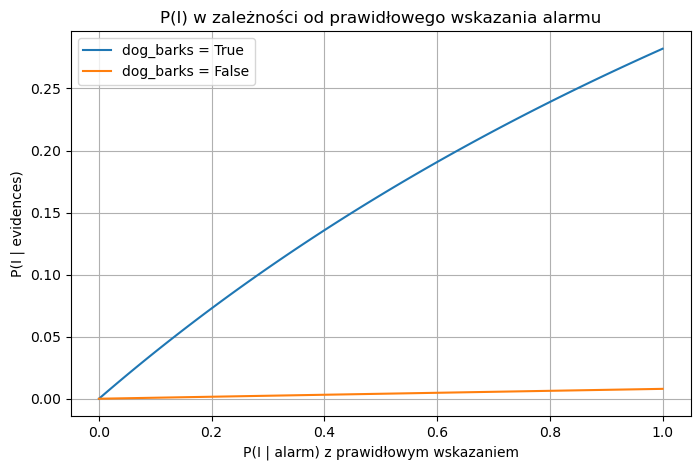

In [14]:
p_vals = np.linspace(0,1,101)

burglar_prob = 0.002

dog_true = []
dog_false = []

for p in p_vals:
    evidence_probs = {
        'alarm': {
            True: {True: p, False: 1 - p},
            False: {True: 0.01, False: 0.99}
        },
        'dog_barks': {
            True: {True: 0.98, False: 0.02},
            False: {True: 0.5, False: 0.5}
        }
    }
    reasoner = BurglarReasoner(burglar_prob=0.002, evidence_probs=evidence_probs)
    reasoner.set_observation('alarm', True)
    
    reasoner.set_observation('dog_barks', True)
    dog_true.append(reasoner.compute())

    reasoner.set_observation('dog_barks', False)
    dog_false.append(reasoner.compute())


plt.figure(figsize=(8,5))
plt.plot(p_vals, dog_true, label='dog_barks = True')
plt.plot(p_vals, dog_false, label='dog_barks = False')
plt.xlabel('P(I | alarm) z prawidłowym wskazaniem')
plt.ylabel('P(I | evidences)')
plt.title('P(I) w zależności od prawidłowego wskazania alarmu')
plt.legend()
plt.grid(True)
plt.show()
    

Prawdopodobieństwo włamania w zależności od prawdopodobieństwa prawdziwej przesłanki psa:

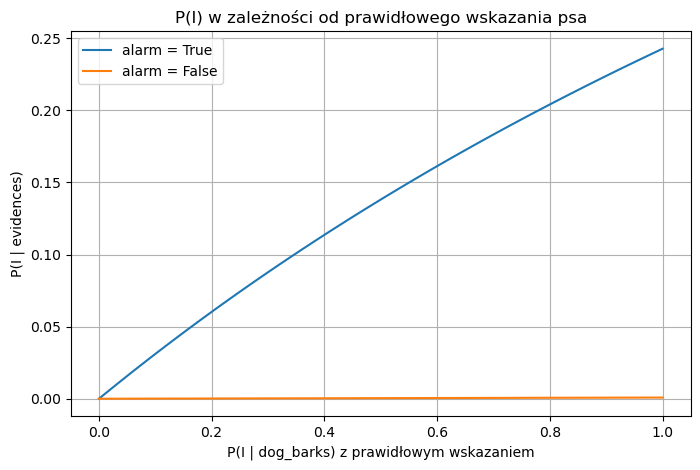

In [ ]:
p_vals = np.linspace(0,1,101)

burglar_prob = 0.002

alarm_true = []
alarm_false = []

for p in p_vals:
    evidence_probs = {
        'alarm': {
            True: {True: 0.8, False: 0.2},
            False: {True: 0.01, False: 0.99}
        },
        'dog_barks': {
            True: {True: p, False: 1 - p},
            False: {True: 0.5, False: 0.5}
        }
    }
    reasoner = BurglarReasoner(burglar_prob=0.002, evidence_probs=evidence_probs)
    reasoner.set_observation('dog_barks', True)
    
    reasoner.set_observation('alarm', True)
    alarm_true.append(reasoner.compute())

    reasoner.set_observation('alarm', False)
    alarm_false.append(reasoner.compute())


plt.figure(figsize=(8,5))
plt.plot(p_vals, alarm_true, label='alarm = True')
plt.plot(p_vals, alarm_false, label='alarm = False')
plt.xlabel('P(I | dog_barks) z prawidłowym wskazaniem')
plt.ylabel('P(I | evidences)')
plt.title('P(I) w zależności od prawidłowego wskazania psa')
plt.legend()
plt.grid(True)
plt.show()
    

# Zadanie 3:

Obliczenia nie zmienią się, jeśli wycie alarmu nie wpływa na szczekanie psa - pies go zignoruje. Zdarzenia są nadal niezależne od siebie.

Natomiast jeśli wpływa i pies szczeka przy wyjącym alarmie, zdarzenia stają się od siebie zależne, co wymaga zmiany obliczeń.